# Lecture 11 — Deep Learning with PyTorch

**Learning objectives**

By the end of this lecture you will be able to:

- Work with PyTorch tensors and explain how reverse-mode automatic differentiation (`autograd`) builds and traverses a computational graph; verify autograd against a hand-derived gradient.
- Structure models with `nn.Module`, data pipelines with `Dataset`/`DataLoader`, and write a standard training loop with validation.
- Explain and evaluate dropout, weight decay and batch normalisation experimentally.
- Derive the convolution operation, implement it in NumPy, and reproduce `torch.nn.functional.conv2d`; compute output shapes, receptive fields and parameter counts.
- Train a small convolutional network on `load_digits`, compare it with an MLP, and inspect its filters and confusion matrix.
- Describe recurrent networks and attention/transformers, implementing scaled dot-product attention in a few lines.
- Explain transfer learning and save/load models correctly.

**Prerequisites**

- [`10_neural_networks_from_scratch.ipynb`](10_neural_networks_from_scratch.ipynb) (MLPs, backpropagation, initialisation, optimisers, overfitting) — this lecture re-implements those ideas with a framework.
- [`04_model_evaluation_and_selection.ipynb`](04_model_evaluation_and_selection.ipynb) (validation sets, confusion matrices).
- [`01_mathematical_foundations.ipynb`](01_mathematical_foundations.ipynb) (matrix calculus).

**Contents**

1. Tensors
2. Autograd
3. `nn.Module`
4. `Dataset` and `DataLoader`
5. A standard training loop with validation
6. Regularisation: dropout, weight decay, batch normalisation
7. Convolutional neural networks
8. A CNN for `load_digits`
9. Inspecting a trained CNN
10. Sequence models: RNNs (conceptual)
11. Attention and transformers
12. Transfer learning
13. Saving and loading models
14. Pitfalls & practical tips
15. Exercises
16. Summary and further reading

In [1]:
%matplotlib inline
import os, time, copy, tempfile, warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)
rng = np.random.default_rng(42)
torch.manual_seed(42)
torch.set_num_threads(2)                  # small models: few threads avoid oversubscription
plt.rcParams["figure.figsize"] = (7, 4.5)
np.set_printoptions(precision=4, suppress=True)
device = torch.device("cpu")      # everything in this notebook runs on CPU
print("PyTorch", torch.__version__, "| device:", device)

PyTorch 2.14.0+cu130 | device: cpu


## 1. Tensors

A `torch.Tensor` is an $n$-dimensional array, much like `np.ndarray`, with three additions that matter for deep learning:

1. it can live on an accelerator (`.to("cuda")`, `.to("mps")`),
2. it can record the operations applied to it so that gradients can be computed automatically (`requires_grad=True`),
3. a large library of differentiable operations (`torch.nn.functional`) is defined on it.

The default floating type is `float32` (NumPy defaults to `float64`) — single precision halves memory and is much faster on GPUs, and the extra precision is rarely useful for noisy stochastic optimisation. Broadcasting and indexing rules are the same as NumPy's.

In [2]:
a = torch.arange(6, dtype=torch.float32).reshape(2, 3)
b = torch.tensor([10.0, 20.0, 30.0])
print("a =\n", a, "\nshape", tuple(a.shape), "dtype", a.dtype)
print("broadcast a + b =\n", a + b)
print("matrix product a @ a.T =\n", a @ a.T)
print("reductions: sum over rows", a.sum(dim=0), "| mean", a.mean().item())

# NumPy interop: torch.from_numpy shares memory with the array (no copy)
arr = np.ones(3)
t = torch.from_numpy(arr)
arr[0] = 99
print("shared memory:", t, "| dtype", t.dtype)
print("back to NumPy:", (t * 2).numpy())

# Views vs copies, and in-place ops (trailing underscore)
v = a.view(3, 2); v[0, 0] = -1
print("a after modifying its view:", a[0])
a.add_(1)   # in-place
print("after in-place add_:", a[0])

a =
 tensor([[0., 1., 2.],
        [3., 4., 5.]]) 
shape (2, 3) dtype torch.float32
broadcast a + b =
 tensor([[10., 21., 32.],
        [13., 24., 35.]])
matrix product a @ a.T =
 tensor([[ 5., 14.],
        [14., 50.]])
reductions: sum over rows tensor([3., 5., 7.]) | mean 2.5
shared memory: tensor([99.,  1.,  1.], dtype=torch.float64) | dtype torch.float64
back to NumPy: [198.   2.   2.]
a after modifying its view: tensor([-1.,  1.,  2.])
after in-place add_: tensor([0., 2., 3.])


## 2. Autograd

When a tensor has `requires_grad=True`, every operation on it creates a node in a **dynamic computational graph** (built *as the code runs* — "define-by-run"). Calling `.backward()` on a scalar $\mathcal L$ traverses the graph in reverse topological order, applying each node's local vector–Jacobian product (VJP), exactly the reverse-mode differentiation derived in Lecture 10:

$$
\bar{\mathbf u} = J_{\mathbf v}(\mathbf u)^\top \bar{\mathbf v}, \qquad \bar{\mathbf v} := \frac{\partial \mathcal L}{\partial \mathbf v}.
$$

Gradients are **accumulated** into the `.grad` field of leaf tensors, which is why training loops call `optimizer.zero_grad()` every step.

**Verification against a manual gradient.** For logistic regression with $\mathcal{L}(\mathbf w) = -\frac1m\sum_i [y_i\log\sigma(\mathbf x_i^\top\mathbf w) + (1-y_i)\log(1-\sigma(\mathbf x_i^\top \mathbf w))] + \frac\lambda2\|\mathbf w\|^2$ we derived (Lecture 03)

$$
\nabla_{\mathbf w}\mathcal L = \frac1m X^\top(\sigma(X\mathbf w) - \mathbf y) + \lambda\mathbf w .
$$

In [3]:
m, d, lam = 50, 4, 0.1
X = torch.randn(m, d, dtype=torch.float64)
y = (torch.rand(m, dtype=torch.float64) < 0.5).double()
w = torch.randn(d, dtype=torch.float64, requires_grad=True)

logits = X @ w
loss = F.binary_cross_entropy_with_logits(logits, y) + 0.5 * lam * (w ** 2).sum()
loss.backward()                                     # populates w.grad

with torch.no_grad():                               # manual gradient, no graph needed
    manual = X.T @ (torch.sigmoid(X @ w) - y) / m + lam * w
print("autograd:", w.grad.numpy())
print("manual  :", manual.numpy())
print("max abs difference:", (w.grad - manual).abs().max().item())
print("grad_fn of the loss:", loss.grad_fn)

# torch.autograd.gradcheck compares against finite differences (use float64)
f = lambda w_: F.binary_cross_entropy_with_logits(X @ w_, y) + 0.5 * lam * (w_ ** 2).sum()
print("gradcheck passed:", torch.autograd.gradcheck(f, (w.detach().clone().requires_grad_(),)))

autograd: [-0.3119 -0.0498  0.0343  0.354 ]
manual  : [-0.3119 -0.0498  0.0343  0.354 ]
max abs difference: 6.938893903907228e-18
grad_fn of the loss: <AddBackward0 object at 0x7fb9208fbe80>


gradcheck passed: True


In [4]:
# Three autograd behaviours every practitioner must know
x = torch.tensor(2.0, requires_grad=True)

# (1) gradients ACCUMULATE across backward calls
(x ** 2).backward(); (x ** 2).backward()
print("accumulated grad (2 * 2x):", x.grad.item())
x.grad.zero_()

# (2) higher-order derivatives: keep the graph of the gradient itself
y3 = x ** 3
(g,) = torch.autograd.grad(y3, x, create_graph=True)   # dy/dx = 3x^2 = 12
(h,) = torch.autograd.grad(g, x)                       # d2y/dx2 = 6x = 12
print("first derivative:", g.item(), "second derivative:", h.item())

# (3) detach / no_grad stop gradient flow
z = x * 3
z_stop = z.detach()                     # a constant w.r.t. x
out = z * z_stop                        # d/dx = 3 * z_stop = 18
out.backward()
print("gradient through detach:", x.grad.item())

accumulated grad (2 * 2x): 8.0
first derivative: 12.0 second derivative: 12.0
gradient through detach: 18.0


## 3. `nn.Module`

`nn.Module` is the building block for models. A module

- registers its **parameters** (`nn.Parameter`, tensors with `requires_grad=True`) and **sub-modules** automatically when you assign them as attributes in `__init__`;
- defines the computation in `forward` (call the module as `model(x)`, which runs hooks and then `forward`);
- exposes `parameters()`, `state_dict()`, `train()`/`eval()` modes (which change the behaviour of dropout and batch norm), and `.to(device)`.

`nn.Linear(n_in, n_out)` computes $XW^\top + \mathbf b$ with $W\in\mathbb{R}^{n_{\text{out}}\times n_{\text{in}}}$ (note the transpose relative to Lecture 10) and uses a uniform "Kaiming-uniform"-style initialisation by default.

In [5]:
class MLP(nn.Module):
    def __init__(self, n_in=64, hidden=(128, 64), n_out=10, p_drop=0.0, batchnorm=False):
        super().__init__()
        layers, prev = [], n_in
        for h in hidden:
            layers.append(nn.Linear(prev, h))
            if batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if p_drop > 0:
                layers.append(nn.Dropout(p_drop))
            prev = h
        layers.append(nn.Linear(prev, n_out))       # logits; softmax is inside the loss
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x.flatten(start_dim=1))     # accept (B, 64) or (B, 1, 8, 8)

def n_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

mlp = MLP()
print(mlp)
print("trainable parameters:", n_params(mlp), "= (64*128+128) + (128*64+64) + (64*10+10) =",
      (64*128+128) + (128*64+64) + (64*10+10))
print("output shape for a batch of 5:", tuple(mlp(torch.randn(5, 64)).shape))

MLP(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)
trainable parameters: 17226 = (64*128+128) + (128*64+64) + (64*10+10) = 17226
output shape for a batch of 5: (5, 10)


## 4. `Dataset` and `DataLoader`

- A **`Dataset`** implements `__len__` and `__getitem__(i)` returning one example (possibly loading it lazily from disk and applying transforms such as augmentation).
- A **`DataLoader`** wraps a dataset and yields **mini-batches**: it shuffles indices each epoch (`shuffle=True`), collates examples into batched tensors, and can load in parallel worker processes (`num_workers`).

For in-memory arrays, `TensorDataset` suffices; we write a custom `Dataset` to show the protocol, including an optional random-shift augmentation.

In [6]:
digits = load_digits()
X_all = (digits.images / 16.0).astype(np.float32)          # (1797, 8, 8), pixel values in [0, 1]
y_all = digits.target.astype(np.int64)

X_trv, X_te, y_trv, y_te = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)
X_tr, X_val, y_tr, y_val = train_test_split(X_trv, y_trv, test_size=0.2, random_state=42, stratify=y_trv)
# standardise with a single mean/std computed on the training images only
mu, sd = X_tr.mean(), X_tr.std()
norm = lambda a: (a - mu) / sd
print("train / val / test:", len(y_tr), len(y_val), len(y_te))

class DigitsDataset(Dataset):
    # 8x8 digit images as (1, 8, 8) tensors; optional random +-1 pixel shift augmentation.
    def __init__(self, images, labels, augment=False):
        self.X = torch.from_numpy(norm(images)).unsqueeze(1)   # add channel dim -> (N, 1, 8, 8)
        self.y = torch.from_numpy(labels)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        x = self.X[i]
        if self.augment:
            dx, dy = torch.randint(-1, 2, (2,)).tolist()
            x = torch.roll(x, shifts=(dy, dx), dims=(1, 2))
        return x, self.y[i]

ds_tr, ds_val, ds_te = DigitsDataset(X_tr, y_tr), DigitsDataset(X_val, y_val), DigitsDataset(X_te, y_te)
g_loader = torch.Generator().manual_seed(42)                  # reproducible shuffling
dl_tr = DataLoader(ds_tr, batch_size=64, shuffle=True, generator=g_loader)
dl_val = DataLoader(ds_val, batch_size=256)
dl_te = DataLoader(ds_te, batch_size=256)
xb, yb = next(iter(dl_tr))
print("one batch:", tuple(xb.shape), xb.dtype, tuple(yb.shape), yb.dtype)

train / val / test: 1149 288 360
one batch: (64, 1, 8, 8) torch.float32 (64,) torch.int64


## 5. A standard training loop with validation

Every PyTorch training loop has the same five steps per mini-batch:

1. `model.train()` (enables dropout, batch-norm batch statistics),
2. forward pass: `logits = model(xb)`, `loss = F.cross_entropy(logits, yb)` (log-softmax + NLL, numerically stable),
3. `optimizer.zero_grad()`,
4. `loss.backward()`,
5. `optimizer.step()`.

After each epoch we evaluate on the validation set in `model.eval()` mode under `torch.no_grad()` (no graph is built, saving memory and time), and keep a copy of the best weights — early stopping from Lecture 10.

In [7]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        logits = model(xb)
        total_loss += F.cross_entropy(logits, yb, reduction="sum").item()
        correct += (logits.argmax(1) == yb).sum().item()
        n += len(yb)
    return total_loss / n, correct / n

def fit(model, dl_train, dl_valid, epochs=30, lr=1e-3, weight_decay=0.0, verbose=False):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    hist = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_acc, best_state = -1.0, None
    for epoch in range(epochs):
        model.train()
        running, n = 0.0, 0
        for xb, yb in dl_train:
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            running += loss.item() * len(yb); n += len(yb)
        val_loss, val_acc = evaluate(model, dl_valid)
        hist["train_loss"].append(running / n); hist["val_loss"].append(val_loss); hist["val_acc"].append(val_acc)
        if val_acc > best_acc:
            best_acc, best_state = val_acc, copy.deepcopy(model.state_dict())
        if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
            print(f"epoch {epoch:3d} | train loss {running / n:.4f} | val loss {val_loss:.4f} | val acc {val_acc:.3f}")
    model.load_state_dict(best_state)          # restore the best validation checkpoint
    hist["best_val_acc"] = best_acc
    return hist

torch.manual_seed(42)
t0 = time.time()
mlp = MLP()
h_mlp = fit(mlp, dl_tr, dl_val, epochs=30, verbose=True)
print(f"time {time.time() - t0:.1f}s | best val acc {h_mlp['best_val_acc']:.3f} | test acc {evaluate(mlp, dl_te)[1]:.3f}")

epoch   0 | train loss 2.1428 | val loss 1.8879 | val acc 0.684


epoch  10 | train loss 0.0918 | val loss 0.1187 | val acc 0.965


epoch  20 | train loss 0.0333 | val loss 0.0873 | val acc 0.976


epoch  29 | train loss 0.0163 | val loss 0.0648 | val acc 0.983
time 1.7s | best val acc 0.983 | test acc 0.975


## 6. Regularisation: dropout, weight decay, batch normalisation

**Dropout (Srivastava et al., 2014).** During training each hidden unit is kept with probability $q = 1-p$ and zeroed otherwise; PyTorch uses *inverted* dropout, scaling kept units by $1/q$ so that $\mathbb E[\tilde a] = a$ and nothing changes at test time:

$$
\tilde{\mathbf a} = \frac{\mathbf r\odot\mathbf a}{q},\qquad r_j \sim \text{Bernoulli}(q).
$$

Interpretations: training an exponential ensemble of weight-sharing "thinned" networks whose predictions are approximately averaged at test time; preventing co-adaptation of features; for linear models it is equivalent in expectation to an adaptive L2 penalty.

**Weight decay.** SGD with `weight_decay=λ` adds $\lambda\theta$ to the gradient, i.e. L2 regularisation. For adaptive optimisers the coupled form interacts with the per-parameter scaling; `torch.optim.AdamW` applies *decoupled* decay $\theta\leftarrow\theta - \eta\lambda\theta$ instead (Loshchilov & Hutter, 2019).

**Batch normalisation (Ioffe & Szegedy, 2015).** For each feature, over a mini-batch $\mathcal B$ of size $m$:

$$
\mu_{\mathcal B} = \frac1m\sum_i z_i,\quad \sigma^2_{\mathcal B} = \frac1m\sum_i (z_i-\mu_{\mathcal B})^2,\quad
\hat z_i = \frac{z_i - \mu_{\mathcal B}}{\sqrt{\sigma^2_{\mathcal B}+\epsilon}},\quad
\text{BN}(z_i) = \gamma\hat z_i + \beta ,
$$

with learnable $\gamma,\beta$. At test time running averages of $\mu,\sigma^2$ collected during training are used (so `model.eval()` is essential). BN smooths the loss landscape (Santurkar et al., 2018), allows larger learning rates, reduces sensitivity to initialisation, and adds mild regularisation through batch noise.

**Experiment.** To make regularisation matter we train a wide MLP ($64\to512\to512\to10$, about 300k parameters) on only **150** training images and compare validation loss and accuracy across settings.

In [8]:
# Verify BatchNorm1d's training-mode output against the formula
bn = nn.BatchNorm1d(3)
z = torch.randn(8, 3) * 5 + 2
out = bn(z)                                           # training mode, gamma=1, beta=0 initially
manual = (z - z.mean(0)) / torch.sqrt(z.var(0, unbiased=False) + bn.eps)
print("BatchNorm matches formula:", torch.allclose(out, manual, atol=1e-5))
print("running mean after one batch (momentum 0.1):", bn.running_mean)

# Verify inverted dropout keeps the expectation
drop = nn.Dropout(p=0.5); ones = torch.ones(100000)
print("mean after dropout (train):", drop(ones).mean().item(), "| eval mode:", drop.eval()(ones).mean().item())

BatchNorm matches formula: True
running mean after one batch (momentum 0.1): tensor([0.2608, 0.2121, 0.3471])
mean after dropout (train): 1.0008200407028198 | eval mode: 1.0


baseline           best val acc 0.941 | min val loss 0.237 (epoch 10) | final val loss 0.259


dropout p=0.5      best val acc 0.955 | min val loss 0.214 (epoch 25) | final val loss 0.231


weight decay 1e-2  best val acc 0.948 | min val loss 0.245 (epoch 52) | final val loss 0.260


batch norm         best val acc 0.938 | min val loss 0.212 (epoch 57) | final val loss 0.215


dropout + BN       best val acc 0.955 | min val loss 0.196 (epoch 51) | final val loss 0.208
(4.6s)


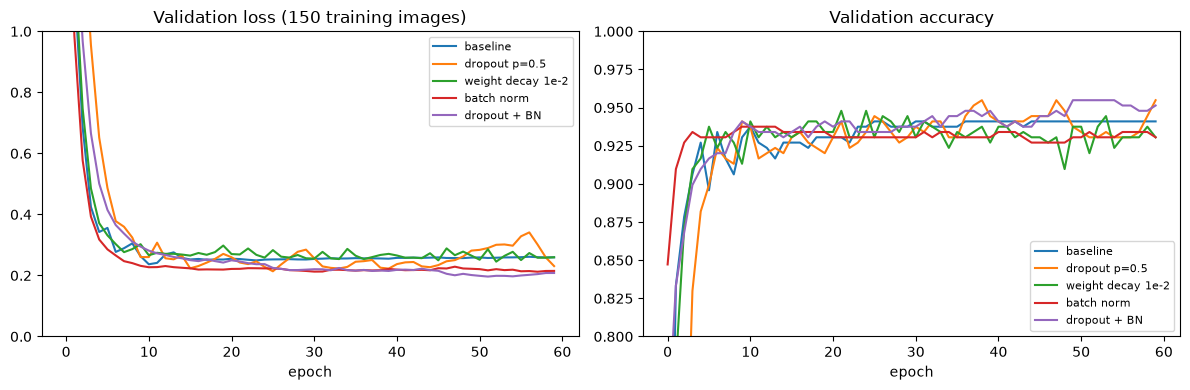

In [9]:
small = rng.choice(len(y_tr), size=150, replace=False)
dl_small = DataLoader(DigitsDataset(X_tr[small], y_tr[small]), batch_size=32, shuffle=True,
                      generator=torch.Generator().manual_seed(0))

settings = {
    "baseline":            dict(p_drop=0.0, batchnorm=False, wd=0.0),
    "dropout p=0.5":       dict(p_drop=0.5, batchnorm=False, wd=0.0),
    "weight decay 1e-2":   dict(p_drop=0.0, batchnorm=False, wd=1e-2),
    "batch norm":          dict(p_drop=0.0, batchnorm=True,  wd=0.0),
    "dropout + BN":        dict(p_drop=0.5, batchnorm=True,  wd=0.0),
}
reg_hist = {}
t0 = time.time()
for name, s in settings.items():
    torch.manual_seed(0)
    model = MLP(hidden=(512, 512), p_drop=s["p_drop"], batchnorm=s["batchnorm"])
    h = fit(model, dl_small, dl_val, epochs=60, lr=1e-3, weight_decay=s["wd"])
    reg_hist[name] = h
    vl = np.array(h["val_loss"])
    print(f"{name:18s} best val acc {h['best_val_acc']:.3f} | min val loss {vl.min():.3f} (epoch {vl.argmin():2d}) "
          f"| final val loss {vl[-1]:.3f}")
print(f"({time.time() - t0:.1f}s)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, h in reg_hist.items():
    axes[0].plot(h["val_loss"], label=name); axes[1].plot(h["val_acc"], label=name)
axes[0].set_title("Validation loss (150 training images)"); axes[1].set_title("Validation accuracy")
for ax in axes: ax.set_xlabel("epoch"); ax.legend(fontsize=8)
axes[0].set_ylim(0, 1.0); axes[1].set_ylim(0.8, 1.0)
plt.tight_layout(); plt.show()

How to read these results: without regularisation the validation loss reaches its minimum after only a few epochs and then creeps upward as the network becomes over-confident on its memorised training set, while validation accuracy plateaus. The regularised variants reach their minimum later and typically at a lower value. Batch normalisation mainly speeds up and stabilises optimisation. Be honest about the size of the effects: $8\times8$ digits are an easy problem, the validation set has fewer than 300 images (one image is about 0.35% accuracy), and differences of 1–2 points are within seed-to-seed noise. Validation *loss* is the more sensitive diagnostic, and a careful comparison would repeat each setting over several seeds.

## 7. Convolutional neural networks

An MLP on images ignores their spatial structure: it treats pixel $(3,4)$ and pixel $(3,5)$ as unrelated features, and a shifted image looks completely different. **Convolutional layers** build in two priors:

- **Locality**: each output depends only on a small $k\times k$ neighbourhood (sparse connectivity).
- **Weight sharing / translation equivariance**: the same filter is applied at every location, so shifting the input shifts the output: $\text{conv}(T_{\delta}x) = T_\delta\,\text{conv}(x)$.

### 7.1 The convolution operation

For an input with $C_{\text{in}}$ channels $X\in\mathbb R^{C_{\text{in}}\times H\times W}$, a layer with $C_{\text{out}}$ filters $K\in\mathbb R^{C_{\text{out}}\times C_{\text{in}}\times k\times k}$ and bias $\mathbf b$ computes (deep-learning "convolution" is technically **cross-correlation** — the kernel is not flipped):

$$
Y_{o,i,j} = b_o + \sum_{c=1}^{C_{\text{in}}}\sum_{u=0}^{k-1}\sum_{v=0}^{k-1} K_{o,c,u,v}\,X_{c,\; s i + u - p,\; s j + v - p},
$$

with stride $s$ and zero padding $p$. The output spatial size is

$$
H_{\text{out}} = \left\lfloor \frac{H + 2p - k}{s}\right\rfloor + 1 .
$$

"Same" padding for odd $k$ and $s=1$ is $p = (k-1)/2$. The backward pass of a convolution is again a convolution (with the flipped kernel for $\bar X$, and input–gradient correlation for $\bar K$), which is why it fits autograd naturally.

**Parameters and cost.** A conv layer has $C_{\text{out}}(C_{\text{in}}k^2 + 1)$ parameters — independent of the image size — and costs $O(C_{\text{out}}C_{\text{in}}k^2 H_{\text{out}}W_{\text{out}})$ multiply-adds.

In [10]:
def conv2d_numpy(X, K, b=None, stride=1, padding=0):
    # Naive multi-channel 2-D cross-correlation.
    # X: (N, C_in, H, W), K: (C_out, C_in, k, k), b: (C_out,)  ->  (N, C_out, H_out, W_out)
    N, C_in, H, W = X.shape
    C_out, _, k, _ = K.shape
    Xp = np.pad(X, ((0, 0), (0, 0), (padding, padding), (padding, padding)))
    H_out = (H + 2 * padding - k) // stride + 1
    W_out = (W + 2 * padding - k) // stride + 1
    Y = np.zeros((N, C_out, H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            patch = Xp[:, :, i * stride:i * stride + k, j * stride:j * stride + k]   # (N, C_in, k, k)
            # contract over (C_in, k, k) for every filter at once
            Y[:, :, i, j] = np.tensordot(patch, K, axes=([1, 2, 3], [1, 2, 3]))
    if b is not None:
        Y += b[None, :, None, None]
    return Y

def maxpool2d_numpy(X, k=2, stride=2):
    N, C, H, W = X.shape
    H_out, W_out = (H - k) // stride + 1, (W - k) // stride + 1
    Y = np.zeros((N, C, H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            Y[:, :, i, j] = X[:, :, i * stride:i * stride + k, j * stride:j * stride + k].max(axis=(2, 3))
    return Y

Xc = rng.standard_normal((2, 3, 8, 8)); Kc = rng.standard_normal((4, 3, 3, 3)); bc = rng.standard_normal(4)
for stride, padding in [(1, 0), (1, 1), (2, 1)]:
    ours = conv2d_numpy(Xc, Kc, bc, stride, padding)
    ref = F.conv2d(torch.from_numpy(Xc), torch.from_numpy(Kc), torch.from_numpy(bc), stride=stride, padding=padding).numpy()
    print(f"stride={stride} pad={padding}: output {ours.shape}, max |diff| vs torch = {np.abs(ours - ref).max():.2e}")
ref_pool = F.max_pool2d(torch.from_numpy(Xc), 2).numpy()
print("max-pool matches torch:", np.allclose(maxpool2d_numpy(Xc), ref_pool))

stride=1 pad=0: output (2, 4, 6, 6), max |diff| vs torch = 0.00e+00
stride=1 pad=1: output (2, 4, 8, 8), max |diff| vs torch = 0.00e+00
stride=2 pad=1: output (2, 4, 4, 4), max |diff| vs torch = 0.00e+00
max-pool matches torch: True


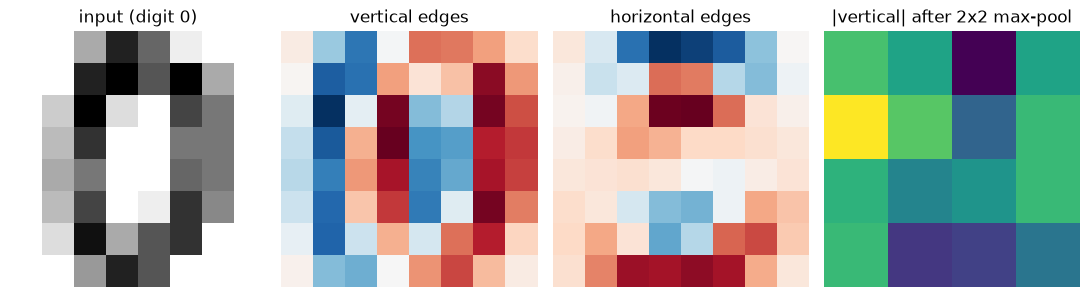

In [11]:
# What does a filter do? Apply two hand-designed edge detectors to a digit image.
img = X_all[0]
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=float)
kernels = np.stack([sobel_x, sobel_x.T])[:, None]            # (2, 1, 3, 3)
maps = conv2d_numpy(img[None, None], kernels, padding=1)[0]

fig, axes = plt.subplots(1, 4, figsize=(11, 3))
axes[0].imshow(img, cmap="gray_r"); axes[0].set_title("input (digit 0)")
axes[1].imshow(maps[0], cmap="RdBu"); axes[1].set_title("vertical edges")
axes[2].imshow(maps[1], cmap="RdBu"); axes[2].set_title("horizontal edges")
axes[3].imshow(maxpool2d_numpy(np.abs(maps)[None])[0, 0], cmap="viridis"); axes[3].set_title("|vertical| after 2x2 max-pool")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

### 7.2 Pooling

**Max pooling** with window $k$ and stride $k$ keeps the largest activation in each window: it reduces spatial resolution (and compute) by $k^2$, and makes the representation approximately *invariant* to small shifts within a window. It has no parameters. Its gradient routes $\bar Y$ to the arg-max location only. Average pooling and strided convolutions are common alternatives; **global average pooling** over the whole map is standard before the classifier in modern CNNs.

### 7.3 Receptive fields

The receptive field (RF) of a unit is the region of the input that can influence it. For a stack of layers with kernel sizes $k_\ell$ and strides $s_\ell$,

$$
r_\ell = r_{\ell-1} + (k_\ell - 1)\prod_{j<\ell}s_j,\qquad r_0 = 1 .
$$

Two stacked $3\times3$ convolutions see $5\times5$ with $2\cdot 9C^2$ parameters versus $25C^2$ for one $5\times5$ layer, and they have an extra nonlinearity — the design argument behind VGG. Pooling/striding multiplies the growth rate of later layers.

### 7.4 Parameter counting

For our digits CNN below: `conv1` $1\to16$, $3\times3$: $16(1\cdot9+1)=160$; `conv2` $16\to32$, $3\times3$: $32(16\cdot9+1) = 4640$; after $2\times2$ pooling the map is $32\times4\times4 = 512$ features; `fc1` $512\to64$: $32832$; `fc2` $64\to10$: $650$.

In [12]:
def receptive_field(layers):
    # layers: list of (name, kernel, stride); returns RF size after each layer
    r, jump, out = 1, 1, []
    for name, k, s in layers:
        r = r + (k - 1) * jump
        jump *= s
        out.append((name, r))
    return out

arch = [("conv1 3x3", 3, 1), ("conv2 3x3", 3, 1), ("maxpool 2x2", 2, 2), ("conv3 3x3", 3, 1)]
for name, r in receptive_field(arch):
    print(f"after {name:12s}: receptive field {r}x{r}")

after conv1 3x3   : receptive field 3x3
after conv2 3x3   : receptive field 5x5
after maxpool 2x2 : receptive field 6x6
after conv3 3x3   : receptive field 10x10


## 8. A CNN for `load_digits`

Architecture: `conv(1→16, 3×3, pad 1) → ReLU → conv(16→32, 3×3, pad 1) → ReLU → maxpool 2×2 → flatten (512) → dropout → linear(512→64) → ReLU → linear(64→10)`. We compare with the MLP of Section 5 trained with the same loop, and additionally test **robustness to one-pixel translations** of the test images — where the inductive bias of convolutions should help.

In [13]:
class DigitCNN(nn.Module):
    def __init__(self, p_drop=0.25):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(),     # (B,16,8,8)
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(),    # (B,32,8,8)
            nn.MaxPool2d(2),                                           # (B,32,4,4)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(p_drop),
            nn.Linear(32 * 4 * 4, 64), nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

cnn = DigitCNN()
for name, p in cnn.named_parameters():
    print(f"{name:22s} {str(tuple(p.shape)):18s} {p.numel():6d}")
print("CNN trainable parameters:", n_params(cnn), "| MLP (Section 5):", n_params(mlp))

features.0.weight      (16, 1, 3, 3)         144
features.0.bias        (16,)                  16
features.2.weight      (32, 16, 3, 3)       4608
features.2.bias        (32,)                  32
classifier.2.weight    (64, 512)           32768
classifier.2.bias      (64,)                  64
classifier.4.weight    (10, 64)              640
classifier.4.bias      (10,)                  10
CNN trainable parameters: 38282 | MLP (Section 5): 17226


CNN trained in 2.4s | best val acc 0.990

test condition        MLP    CNN
shift (+0,+0)       0.975  0.981
shift (+1,+0)       0.431  0.631
shift (+0,+1)       0.522  0.661
shift (-1,-1)       0.172  0.242


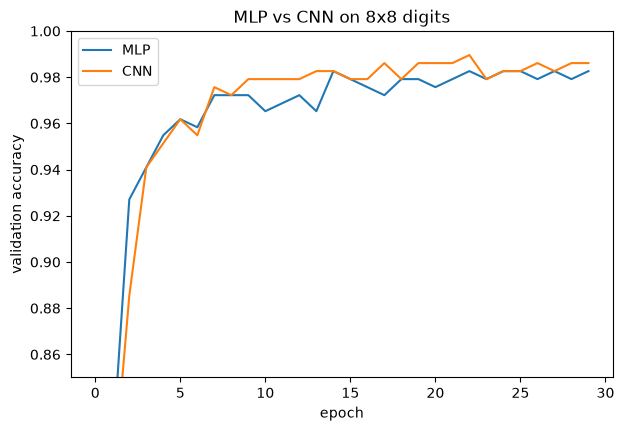

In [14]:
torch.manual_seed(42)
t0 = time.time()
cnn = DigitCNN()
h_cnn = fit(cnn, dl_tr, dl_val, epochs=30, lr=1e-3)
print(f"CNN trained in {time.time() - t0:.1f}s | best val acc {h_cnn['best_val_acc']:.3f}")

def shifted_loader(images, labels, dx, dy):
    shifted = np.roll(images, shift=(dy, dx), axis=(1, 2))
    return DataLoader(DigitsDataset(shifted, labels), batch_size=256)

print(f"\n{'test condition':18s} {'MLP':>6s} {'CNN':>6s}")
for dx, dy in [(0, 0), (1, 0), (0, 1), (-1, -1)]:
    dl = shifted_loader(X_te, y_te, dx, dy)
    print(f"shift ({dx:+d},{dy:+d})      {evaluate(mlp, dl)[1]:6.3f} {evaluate(cnn, dl)[1]:6.3f}")

fig, ax = plt.subplots()
ax.plot(h_mlp["val_acc"], label="MLP"); ax.plot(h_cnn["val_acc"], label="CNN")
ax.set_xlabel("epoch"); ax.set_ylabel("validation accuracy"); ax.set_ylim(0.85, 1.0); ax.legend()
ax.set_title("MLP vs CNN on 8x8 digits"); plt.show()

On clean data both models do well — $8\times8$ digits are an easy problem — but the CNN is markedly more robust to one-pixel shifts that neither model saw during training. Training with the random-shift augmentation built into `DigitsDataset(augment=True)` would further close the gap for both (Exercise 3).

## 9. Inspecting a trained CNN

Looking inside a network is a useful debugging tool: first-layer filters of a well-trained image model tend to be smooth, oriented edge/blob detectors, and feature maps show *where* each filter responds. The confusion matrix shows *which* classes are confused.

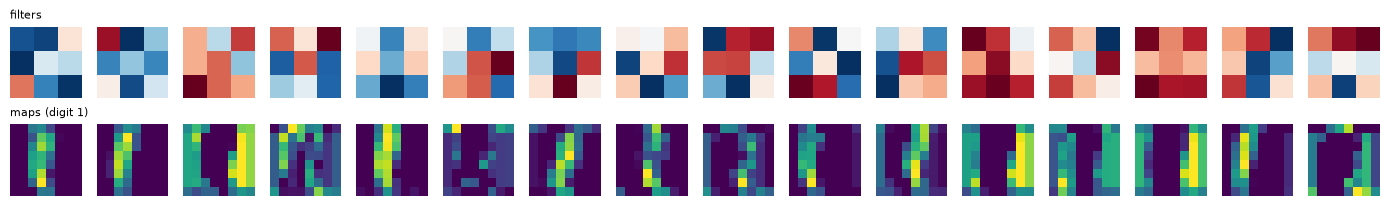

In [15]:
W1 = cnn.features[0].weight.detach().numpy()[:, 0]           # (16, 3, 3)
fig, axes = plt.subplots(2, 16, figsize=(14, 2.2))
x0 = ds_te[3][0].unsqueeze(0)
with torch.no_grad():
    fmap = F.relu(cnn.features[0](x0))[0].numpy()             # (16, 8, 8)
for i in range(16):
    v = np.abs(W1[i]).max()
    axes[0, i].imshow(W1[i], cmap="RdBu", vmin=-v, vmax=v)
    axes[1, i].imshow(fmap[i], cmap="viridis")
    axes[0, i].axis("off"); axes[1, i].axis("off")
axes[0, 0].set_title("filters", fontsize=8, loc="left"); axes[1, 0].set_title(f"maps (digit {ds_te[3][1].item()})", fontsize=8, loc="left")
plt.tight_layout(); plt.show()

CNN test accuracy: 0.9806


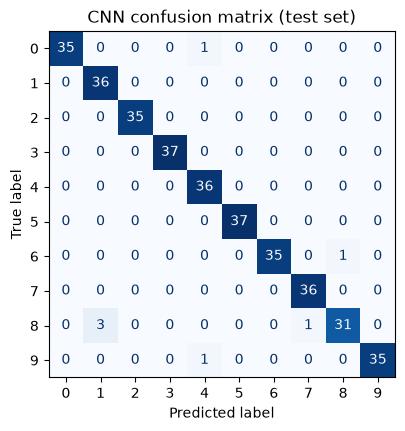

most frequent confusion: true 8 predicted as 1 (3 times)


In [16]:
@torch.no_grad()
def predict(model, loader):
    model.eval()
    return torch.cat([model(xb).argmax(1) for xb, _ in loader]).numpy()

pred_cnn = predict(cnn, dl_te)
print("CNN test accuracy:", (pred_cnn == y_te).mean().round(4))
cm = confusion_matrix(y_te, pred_cnn)
ConfusionMatrixDisplay(cm, display_labels=range(10)).plot(cmap="Blues", colorbar=False)
plt.title("CNN confusion matrix (test set)"); plt.show()

off = cm - np.diag(np.diag(cm))
i, j = np.unravel_index(off.argmax(), off.shape)
print(f"most frequent confusion: true {i} predicted as {j} ({off[i, j]} times)")

## 10. Sequence models: recurrent neural networks (conceptual)

For sequences $\mathbf x_1,\dots,\mathbf x_T$ (text, time series, audio) a **recurrent neural network** maintains a hidden state updated by the same parameters at every step:

$$
\mathbf h_t = \tanh(W_{hh}\mathbf h_{t-1} + W_{xh}\mathbf x_t + \mathbf b_h),\qquad \mathbf{\hat y}_t = W_{hy}\mathbf h_t + \mathbf b_y .
$$

Weight sharing across time lets it handle variable-length inputs with a fixed number of parameters. Training uses **backpropagation through time** (BPTT): unroll the recurrence into a deep feed-forward graph of depth $T$ and backpropagate. The gradient w.r.t. an early state contains the product

$$
\frac{\partial \mathbf h_T}{\partial \mathbf h_t} = \prod_{s=t+1}^{T} \operatorname{diag}\bigl(1-\mathbf h_s^2\bigr)W_{hh},
$$

whose norm typically shrinks or grows **exponentially** in $T-t$ (governed by the singular values of $W_{hh}$): vanishing/exploding gradients over long horizons (Bengio et al., 1994). Remedies: gradient clipping (for explosion), and gated architectures — the **LSTM** (Hochreiter & Schmidhuber, 1997) and **GRU** (Cho et al., 2014) — whose additive cell-state update $\mathbf c_t = \mathbf f_t\odot\mathbf c_{t-1} + \mathbf i_t\odot\tilde{\mathbf c}_t$ lets gradients flow through time when the forget gate $\mathbf f_t\approx 1$.

Below we check the shapes of `nn.RNN`/`nn.LSTM` and measure the vanishing gradient of an untrained vanilla RNN numerically.

In [17]:
torch.manual_seed(42)
B, T, d_in, d_h = 4, 50, 3, 16
seq = torch.randn(B, T, d_in)
rnn, lstm = nn.RNN(d_in, d_h, batch_first=True), nn.LSTM(d_in, d_h, batch_first=True)
out, h_T = rnn(seq)
print("RNN output", tuple(out.shape), "final state", tuple(h_T.shape), "| params:", n_params(rnn),
      "=", d_h * (d_in + d_h + 2))
print("LSTM params:", n_params(lstm), "= 4x the RNN (input, forget, cell, output gates)")

# Gradient of the last hidden state w.r.t. the input at each time step
for name, model in [("RNN", rnn), ("LSTM", lstm)]:
    x = seq.clone().requires_grad_(True)
    o = model(x)[0]
    o[:, -1].sum().backward()
    gnorm = x.grad.norm(dim=(0, 2))
    print(f"{name:26s}: ||dh_T/dx_t|| at t = T-1, T-10, T-25, 0: " + ", ".join(f"{gnorm[t]:.1e}" for t in [T-1, T-10, T-25, 0]))

# At initialisation the forget gate is about sigmoid(0) = 0.5, so an untrained LSTM also forgets quickly.
# A common trick (Jozefowicz et al., 2015) is a positive forget-gate bias, i.e. f_t close to 1 initially.
with torch.no_grad():
    lstm.bias_ih_l0[d_h:2 * d_h] += 3.0          # PyTorch gate order: input, forget, cell, output
x = seq.clone().requires_grad_(True)
lstm(x)[0][:, -1].sum().backward()
gnorm = x.grad.norm(dim=(0, 2))
print(f"{'LSTM, forget bias +3':26s}: ||dh_T/dx_t|| at t = T-1, T-10, T-25, 0: " + ", ".join(f"{gnorm[t]:.1e}" for t in [T-1, T-10, T-25, 0]))

RNN output (4, 50, 16) final state (1, 4, 16) | params: 336 = 336
LSTM params: 1344 = 4x the RNN (input, forget, cell, output gates)


RNN                       : ||dh_T/dx_t|| at t = T-1, T-10, T-25, 0: 2.0e+00, 2.0e-03, 1.2e-07, 1.3e-14
LSTM                      : ||dh_T/dx_t|| at t = T-1, T-10, T-25, 0: 2.7e-01, 4.2e-03, 7.5e-06, 9.3e-11
LSTM, forget bias +3      : ||dh_T/dx_t|| at t = T-1, T-10, T-25, 0: 6.7e-01, 9.7e-02, 1.3e-01, 4.1e-01


The vanilla RNN's sensitivity to inputs 25 steps back is many orders of magnitude smaller than to the most recent input. An *untrained* LSTM with default initialisation also forgets quickly, because its forget gate starts at $\sigma(0)=0.5$; with the forget-gate bias initialised to a positive value, $\mathbf f_t\approx\sigma(3)\approx0.95$ and gradients from far in the past survive much better. Gating only *allows* long memory — training has to learn to use it.

## 11. Attention and transformers

RNNs process tokens sequentially and must squeeze the past into a fixed-size state. **Attention** lets every position directly look up information from every other position. Given queries $Q\in\mathbb R^{n\times d_k}$, keys $K\in\mathbb R^{m\times d_k}$ and values $V\in\mathbb R^{m\times d_v}$, **scaled dot-product attention** (Vaswani et al., 2017) is

$$
\operatorname{Attention}(Q,K,V) = \operatorname{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}} + M\right)V,
$$

where the softmax is taken row-wise and $M$ is an optional mask ($-\infty$ at forbidden positions, e.g. future tokens for causal language modelling). Each output row is a convex combination of value vectors, weighted by query–key similarity.

*Why $\sqrt{d_k}$?* If the components of $\mathbf q,\mathbf k$ are independent with mean 0 and variance 1, then $\operatorname{Var}(\mathbf q^\top\mathbf k) = d_k$. Dividing by $\sqrt{d_k}$ keeps the logits at unit scale so that the softmax does not saturate (which would make its gradients vanish).

**Transformer building blocks.** In *self*-attention, $Q = XW_Q$, $K = XW_K$, $V = XW_V$ are projections of the same sequence $X$. **Multi-head** attention runs $h$ attentions with smaller $d_k = d_{\text{model}}/h$ in parallel and concatenates them, letting heads specialise. A transformer block is `x + MHA(LN(x))` followed by `x + MLP(LN(x))` (pre-norm residual form). Since attention is permutation-equivariant, **positional encodings** are added to the inputs. Cost is $O(n^2 d)$ in sequence length $n$ — the price for $O(1)$ path length between any two tokens.

output shape: (1, 6, 8)
matches F.scaled_dot_product_attention: True
rows of the attention matrix sum to 1: True
d_k=   4: Var(q.k) =     4.2,  Var(q.k/sqrt(d_k)) = 1.04
d_k=  64: Var(q.k) =    62.0,  Var(q.k/sqrt(d_k)) = 0.97
d_k= 512: Var(q.k) =   517.8,  Var(q.k/sqrt(d_k)) = 1.01


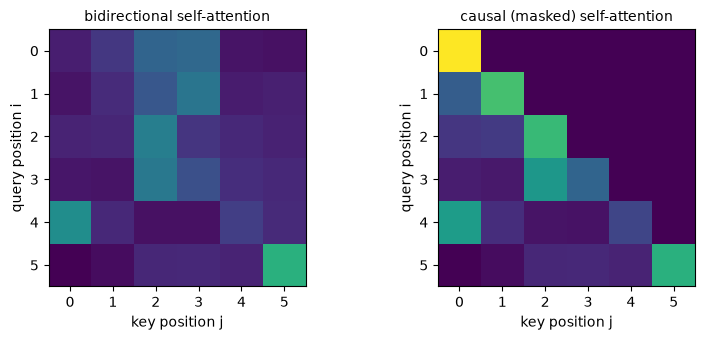

In [18]:
def attention(Q, K, V, mask=None):
    # Scaled dot-product attention. Q: (..., n, d_k), K: (..., m, d_k), V: (..., m, d_v)
    scores = Q @ K.transpose(-2, -1) / Q.shape[-1] ** 0.5          # (..., n, m)
    if mask is not None:
        scores = scores.masked_fill(~mask, float("-inf"))           # mask: True = allowed
    weights = scores.softmax(dim=-1)
    return weights @ V, weights

torch.manual_seed(42)
n, d_k = 6, 8
Xtok = torch.randn(1, n, d_k)                                      # a toy "sentence" of 6 tokens
Wq, Wk, Wv = (torch.randn(d_k, d_k) / d_k ** 0.5 for _ in range(3))
Q, K, V = Xtok @ Wq, Xtok @ Wk, Xtok @ Wv
causal = torch.tril(torch.ones(n, n, dtype=torch.bool))            # token i may attend to j <= i

out_full, w_full = attention(Q, K, V)
out_causal, w_causal = attention(Q, K, V, mask=causal)
ref = F.scaled_dot_product_attention(Q, K, V, is_causal=True)      # PyTorch's fused implementation
print("output shape:", tuple(out_causal.shape))
print("matches F.scaled_dot_product_attention:", torch.allclose(out_causal, ref, atol=1e-6))
print("rows of the attention matrix sum to 1:", torch.allclose(w_causal.sum(-1), torch.ones(1, n)))

# Why scale by sqrt(d_k): variance of raw dot products grows with d_k
for dk in [4, 64, 512]:
    q, k = torch.randn(10000, dk), torch.randn(10000, dk)
    print(f"d_k={dk:4d}: Var(q.k) = {(q * k).sum(1).var():7.1f},  Var(q.k/sqrt(d_k)) = {((q * k).sum(1) / dk**0.5).var():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, w_, t in zip(axes, [w_full, w_causal], ["bidirectional self-attention", "causal (masked) self-attention"]):
    ax.imshow(w_[0].detach(), cmap="viridis", vmin=0, vmax=1); ax.set_title(t, fontsize=10)
    ax.set_xlabel("key position j"); ax.set_ylabel("query position i")
plt.tight_layout(); plt.show()

In [19]:
# nn.MultiheadAttention wraps projections + several heads; check the permutation equivariance of self-attention
torch.manual_seed(42)
mha = nn.MultiheadAttention(embed_dim=8, num_heads=2, batch_first=True)
perm = torch.randperm(n)
y1, _ = mha(Xtok, Xtok, Xtok)
y2, _ = mha(Xtok[:, perm], Xtok[:, perm], Xtok[:, perm])
print("MHA parameters:", n_params(mha), "(= 4 * (8*8 + 8) for Q, K, V and output projections)")
print("permuting the tokens permutes the outputs:", torch.allclose(y1[:, perm], y2, atol=1e-6))

MHA parameters: 288 (= 4 * (8*8 + 8) for Q, K, V and output projections)
permuting the tokens permutes the outputs: True


## 12. Transfer learning

Deep networks learn *hierarchical* features: early layers capture generic patterns (edges, textures, n-grams), later layers task-specific ones. **Transfer learning** reuses a network pre-trained on a large source task for a target task with little data:

- **Feature extraction**: freeze the pre-trained backbone (`requires_grad_(False)`) and train only a new head.
- **Fine-tuning**: initialise from the pre-trained weights and train all (or the top) layers with a small learning rate.

In practice one loads e.g. an ImageNet-pre-trained ResNet or a pre-trained language model (from `torchvision.models` or model hubs) — that needs downloads, so here we simulate the idea offline: **pre-train** the CNN on digits 0–4, then transfer to the *new classes* 5–9 using only **5 labelled images per class**. We compare four strategies on the target test set, averaged over 3 random draws of the 25 training images:

- **scratch**: train the whole CNN from random initialisation;
- **linear probe (random)**: freeze a *randomly initialised* network and train only the final linear layer — a control;
- **linear probe (pre-trained)**: freeze the pre-trained network and train only the final linear layer;
- **fine-tuning**: start from the pre-trained weights and train everything.

In [20]:
src_tr, src_val = y_tr < 5, y_val < 5
tgt_val, tgt_te = y_val >= 5, y_te >= 5

def loader(images, labels, shuffle=False, bs=64):
    return DataLoader(DigitsDataset(images, labels), batch_size=bs, shuffle=shuffle,
                      generator=torch.Generator().manual_seed(0) if shuffle else None)

# 1) pre-train on the source task (labels 0..4, about 570 images)
torch.manual_seed(0)
source_net = DigitCNN()
h_src = fit(source_net, loader(X_tr[src_tr], y_tr[src_tr], True), loader(X_val[src_val], y_val[src_val]), epochs=15)
print(f"source task (digits 0-4) val acc: {h_src['best_val_acc']:.3f}")

# 2) target task: labels 5..9 mapped to 0..4
dl_tgt_val = loader(X_val[tgt_val], y_val[tgt_val] - 5)
dl_tgt_te = loader(X_te[tgt_te], y_te[tgt_te] - 5)

def make_target_model(mode, seed):
    torch.manual_seed(seed)
    net = DigitCNN()
    if mode in ("linear probe (pre-trained)", "fine-tuning"):
        net.load_state_dict(source_net.state_dict())      # copy pre-trained weights
    if mode.startswith("linear probe"):
        for p in net.parameters():
            p.requires_grad_(False)                       # freeze everything ...
    net.classifier[-1] = nn.Linear(64, 5)                 # ... except a new head for the new classes
    return net

modes = ["scratch", "linear probe (random)", "linear probe (pre-trained)", "fine-tuning"]
tl_results = {m: [] for m in modes}
for seed in range(3):
    r = np.random.default_rng(seed)
    tgt_idx = np.concatenate([r.choice(np.where(y_tr == c)[0], 5, replace=False) for c in range(5, 10)])
    dl_tgt = loader(X_tr[tgt_idx], y_tr[tgt_idx] - 5, True, bs=16)
    for mode in modes:
        net = make_target_model(mode, seed)
        fit(net, dl_tgt, dl_tgt_val, epochs=30, lr=1e-2 if mode.startswith("linear") else 1e-3)
        tl_results[mode].append(evaluate(net, dl_tgt_te)[1])
for mode in modes:
    net = make_target_model(mode, 0)
    print(f"{mode:28s} trainable params {n_params(net):6d} | target test acc "
          f"{np.mean(tl_results[mode]):.3f} +- {np.std(tl_results[mode]):.3f}")

source task (digits 0-4) val acc: 0.993


scratch                      trainable params  37957 | target test acc 0.928 +- 0.048
linear probe (random)        trainable params    325 | target test acc 0.717 +- 0.061
linear probe (pre-trained)   trainable params    325 | target test acc 0.739 +- 0.018
fine-tuning                  trainable params  37957 | target test acc 0.902 +- 0.033


Two lessons, both important in practice:

1. **Frozen features are a strong baseline, random or not.** A linear classifier on top of a frozen network reaches well above chance (20%) even with *random* weights — random convolutional features are surprisingly informative (compare the random ReLU features of Lecture 10, Section 3). The pre-trained features are somewhat better and less variable across draws, but here the gap is small, because features learned from five other digits on $8\times8$ images are not much more general than random ones.
2. **Transfer is not automatically a win.** On this tiny, easy problem, training the small CNN from scratch (with early stopping on a validation set) is as good as or better than fine-tuning: the source task (570 images of five other digits) is not much richer than the target, and the network is small. Transfer learning pays off when the source is *large and diverse* (ImageNet, web-scale text) and the target model is large relative to the target data. When source and target are too dissimilar, transfer can even hurt ("negative transfer"). Note also that selecting the best epoch on the target validation set is part of the training protocol here; the reported numbers are on a separate test set.

## 13. Saving and loading models

The recommended way is to save the **`state_dict`** — an ordered dictionary of parameter and buffer tensors (e.g. batch-norm running statistics) — rather than pickling the whole model object, which ties the file to your exact class definitions and module paths. To resume training, also save the optimiser's `state_dict` (Adam's moment estimates), the epoch and any scheduler state. When loading for inference, call `model.eval()`. Loading untrusted files: `torch.load(..., weights_only=True)` restricts unpickling to tensors and primitive types.

In [21]:
with tempfile.TemporaryDirectory() as tmp:
    path = os.path.join(tmp, "digit_cnn.pt")
    torch.save(cnn.state_dict(), path)
    print("saved", os.path.basename(path), f"({os.path.getsize(path) / 1024:.1f} KiB)")
    print("state_dict keys:", list(cnn.state_dict().keys())[:4], "...")

    restored = DigitCNN()                                 # must rebuild the same architecture
    restored.load_state_dict(torch.load(path, weights_only=True))
    restored.eval()
    same = np.array_equal(predict(restored, dl_te), pred_cnn)
    print("restored model gives identical test predictions:", same)

    # A full training checkpoint
    opt = torch.optim.Adam(restored.parameters(), lr=1e-3)
    ckpt = {"epoch": 30, "model": restored.state_dict(), "optimizer": opt.state_dict(), "val_acc": h_cnn["best_val_acc"]}
    torch.save(ckpt, os.path.join(tmp, "checkpoint.pt"))
    print("checkpoint keys:", list(torch.load(os.path.join(tmp, "checkpoint.pt"), weights_only=True).keys()))

saved digit_cnn.pt (153.3 KiB)
state_dict keys: ['features.0.weight', 'features.0.bias', 'features.2.weight', 'features.2.bias'] ...
restored model gives identical test predictions: True
checkpoint keys: ['epoch', 'model', 'optimizer', 'val_acc']


## 14. Pitfalls & practical tips

- **Forgetting `optimizer.zero_grad()`** accumulates gradients across steps — a silent bug.
- **Forgetting `model.eval()`** at validation/test time leaves dropout active and makes batch norm use (noisy) batch statistics; forgetting `model.train()` afterwards disables them during training.
- **Evaluate under `torch.no_grad()`** (or `torch.inference_mode()`) to save memory and time.
- **`F.cross_entropy` expects raw logits** and integer class labels; do not apply softmax first (double softmax trains poorly), and do not use `NLLLoss` without `log_softmax`.
- **Dtype/shape mismatches**: labels must be `int64` for `cross_entropy`; image tensors are `(N, C, H, W)`; watch out for silent broadcasting, e.g. `(N,1) - (N,)` gives `(N,N)`.
- **Use `.item()` or `.detach()`** when logging losses; storing tensors that require grad keeps entire graphs alive (memory leak).
- **Reproducibility**: set `torch.manual_seed`, seed the `DataLoader` generator, and note that some GPU kernels are non-deterministic (`torch.use_deterministic_algorithms(True)`).
- **Batch norm with tiny batches** (e.g. $< 8$) gives noisy statistics; consider group/layer normalisation.
- **Overfit a single batch first** as a sanity check, then scale up; monitor both loss and accuracy on train and validation.
- **Save `state_dict`s**, not pickled models, and store the preprocessing statistics (here `mu`, `sd`) with the model — a model is useless without its input pipeline.

## 15. Exercises

**Exercise 1 (pen and paper, convolution backward pass).** For a single-channel convolution $Y = X \star K$ (stride 1, no padding), show that $\bar K = X \star \bar Y$ and that $\bar X$ is the "full" convolution of $\bar Y$ with the $180^\circ$-rotated kernel. Verify your formulas numerically against autograd using the starter below.

**Exercise 2 (pen and paper, receptive fields and parameters).** A network has layers conv $5\times5$ (stride 1) → maxpool $2\times2$ → conv $3\times3$ (stride 2) → conv $3\times3$ (stride 1), with 3 → 32 → 32 → 64 channels on a $32\times32$ input with "same"-style padding where possible. Compute each layer's output size, receptive field, and parameter count. How many parameters would a fully connected layer mapping the input to a map of the same size as conv1's output need?

**Exercise 3 (coding, data augmentation).** Train both the MLP and the CNN with `DigitsDataset(..., augment=True)` and re-run the shift-robustness table of Section 8. Which model benefits more, and why?

**Exercise 4 (coding, BatchNorm from scratch).** Implement a `MyBatchNorm1d(nn.Module)` with learnable $\gamma,\beta$, running statistics (momentum 0.1, unbiased variance for the running estimate as in PyTorch), and correct train/eval behaviour. Check it against `nn.BatchNorm1d` in both modes.

**Exercise 5 (coding, a tiny transformer classifier).** Treat each $8\times8$ digit as a sequence of 8 row-tokens of dimension 8. Build a classifier: linear embedding to $d=32$, learned positional embeddings, one pre-norm transformer block (multi-head attention + MLP, residual connections), mean-pooling, and a linear head. Compare its accuracy and parameter count with the CNN.

**Exercise 6 (discussion, transfer learning).** In Section 12, when would feature extraction beat fine-tuning, and vice versa? Relate your answer to the bias–variance trade-off and to the similarity between source and target domains.

In [22]:
# Exercise 1 starter: verify the convolution gradients against autograd
def conv_grads_manual(X, K, Ybar):
    # X: (H, W), K: (k, k), Ybar: (H-k+1, W-k+1) as NumPy arrays
    # TODO: return (Xbar, Kbar) computed with conv2d_numpy (hint: use padding k-1 and a flipped kernel for Xbar)
    return None, None

Xe = torch.randn(1, 1, 6, 6, dtype=torch.float64, requires_grad=True)
Ke = torch.randn(1, 1, 3, 3, dtype=torch.float64, requires_grad=True)
Ye = F.conv2d(Xe, Ke); Ybar = torch.randn_like(Ye)
(Ye * Ybar).sum().backward()                   # autograd reference: Xe.grad, Ke.grad
Xbar, Kbar = conv_grads_manual(Xe.detach().numpy()[0, 0], Ke.detach().numpy()[0, 0], Ybar.numpy()[0, 0])
if Xbar is not None:
    print(np.allclose(Xbar, Xe.grad.numpy()[0, 0]), np.allclose(Kbar, Ke.grad.numpy()[0, 0]))

In [23]:
# Exercise 4 starter
class MyBatchNorm1d(nn.Module):
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        super().__init__()
        self.eps, self.momentum = eps, momentum
        self.gamma = nn.Parameter(torch.ones(num_features))
        self.beta = nn.Parameter(torch.zeros(num_features))
        self.register_buffer("running_mean", torch.zeros(num_features))
        self.register_buffer("running_var", torch.ones(num_features))

    def forward(self, x):
        # TODO: in training mode use batch statistics and update the running buffers;
        #       in eval mode use the running statistics.
        raise NotImplementedError

In [24]:
# Exercise 5 starter
class RowTransformer(nn.Module):
    def __init__(self, d_model=32, n_heads=4, n_classes=10):
        super().__init__()
        # TODO: embedding nn.Linear(8, d_model), positional nn.Parameter(torch.zeros(1, 8, d_model)),
        #       LayerNorms, nn.MultiheadAttention, MLP, and the classification head
        pass

    def forward(self, x):          # x: (B, 1, 8, 8)
        # TODO: tokens = x.squeeze(1) -> (B, 8, 8) rows as tokens
        pass

## 16. Summary

- PyTorch tensors are GPU-capable NumPy-like arrays; autograd builds a dynamic graph and computes gradients by reverse-mode differentiation — we verified it against the analytic logistic-regression gradient and finite differences.
- Models are `nn.Module`s; data flows through `Dataset`/`DataLoader`; every training loop is forward → loss → `zero_grad` → `backward` → `step`, with evaluation in `eval()` mode under `no_grad()`.
- Dropout, weight decay and batch normalisation regularise and stabilise training; their effect is clearest on small datasets and in the validation loss.
- Convolutions exploit locality and weight sharing; output size $\lfloor (H+2p-k)/s\rfloor + 1$, parameters $C_{\text{out}}(C_{\text{in}}k^2+1)$, receptive fields grow with depth and stride. Our NumPy convolution reproduces `F.conv2d` exactly.
- A small CNN matches an MLP on clean $8\times8$ digits and is much more robust to shifts; learned filters and the confusion matrix help diagnose the model.
- RNNs share weights over time but suffer from vanishing/exploding gradients; LSTMs/GRUs mitigate this. Attention, $\operatorname{softmax}(QK^\top/\sqrt{d_k})V$, connects all positions directly and is the core of transformers.
- Transfer learning reuses pre-trained features when labelled data are scarce. Save and load `state_dict`s (plus optimiser state for checkpoints).

## Further reading

- Goodfellow, Bengio & Courville, *Deep Learning* (2016): Ch. 7 (regularisation, dropout), Ch. 8 (optimisation, batch normalisation), Ch. 9 (convolutional networks), Ch. 10 (sequence modelling, RNNs, LSTMs).
- Murphy, *Probabilistic Machine Learning: An Introduction* (2022): Ch. 14 (CNNs), Ch. 15 (RNNs, attention and transformers).
- James et al., *ISLP* (2023): Ch. 10 (deep learning: CNNs, RNNs, with PyTorch labs).
- Géron, *Hands-On Machine Learning* (3rd ed.): Ch. 11, 14–16.
- Bishop & Bishop, *Deep Learning: Foundations and Concepts* (2024): Ch. 10 (CNNs), Ch. 12 (transformers).
- Paszke et al. (2019), "PyTorch: An imperative style, high-performance deep learning library"; the official PyTorch tutorials.
- LeCun et al. (1998), "Gradient-based learning applied to document recognition"; Krizhevsky, Sutskever & Hinton (2012), AlexNet; He et al. (2016), "Deep residual learning".
- Srivastava et al. (2014), "Dropout"; Ioffe & Szegedy (2015), "Batch normalization"; Santurkar et al. (2018), "How does batch normalization help optimization?".
- Hochreiter & Schmidhuber (1997), "Long short-term memory"; Bahdanau, Cho & Bengio (2015), "Neural machine translation by jointly learning to align and translate"; Vaswani et al. (2017), "Attention is all you need".
- Yosinski et al. (2014), "How transferable are features in deep neural networks?".